In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import tensorflow.random as tf_r
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input
from scipy.optimize import curve_fit

import BuildModel as BM
import time
import os
import random

plt.rcParams['font.size'] = 14

np.random.seed(12345)
tf_r.set_seed(12345)

In [10]:
np.random.seed(12345)

jump = lambda drift1, drift2, std1, std2: [int(np.random.normal(drift1,std1)), int(np.random.normal(drift2, std2))]

def pattern(i,z1,z2,a1,a2):
    return [int(a1*np.sin((np.pi*i)/z1)), int(a2*np.sin((np.pi*i)/z2))]

In [11]:
twoSNRs = [0.1, 0.3, 1, 3, 10,30]


Generating datasets...


RUN 1/10

Training SNR = 0.05


/home/lenovo/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ACC = 0.3500 | time = 6.1s
Training SNR = 0.15
ACC = 0.3370 | time = 3.3s
Training SNR = 0.5
ACC = 0.3660 | time = 7.2s
Training SNR = 1.5
ACC = 0.4805 | time = 7.4s
Training SNR = 5
ACC = 0.8435 | time = 13.9s
Training SNR = 15
ACC = 0.9945 | time = 12.2s

RUN 2/10

Training SNR = 0.05
ACC = 0.3415 | time = 3.6s
Training SNR = 0.15
ACC = 0.3440 | time = 3.1s
Training SNR = 0.5
ACC = 0.3610 | time = 4.8s
Training SNR = 1.5
ACC = 0.5050 | time = 9.7s
Training SNR = 5
ACC = 0.8505 | time = 14.2s
Training SNR = 15
ACC = 0.9920 | time = 10.0s

RUN 3/10

Training SNR = 0.05
ACC = 0.3400 | time = 2.9s
Training SNR = 0.15
ACC = 0.3525 | time = 4.5s
Training SNR = 0.5
ACC = 0.3630 | time = 3.4s
Training SNR = 1.5
ACC = 0.4935 | time = 5.7s
Training SNR = 5
ACC = 0.8450 | time = 12.5s
Training SNR = 15
ACC = 0.9930 | time = 9.5s

RUN 4/10

Training SNR = 0.05
ACC = 0.3440 | time = 4.1s
Training SNR = 0.15
ACC = 0.3405 | time = 4.5s
Training SNR = 0.5
ACC = 0.3645 | time = 5.9s
Training SNR = 1.

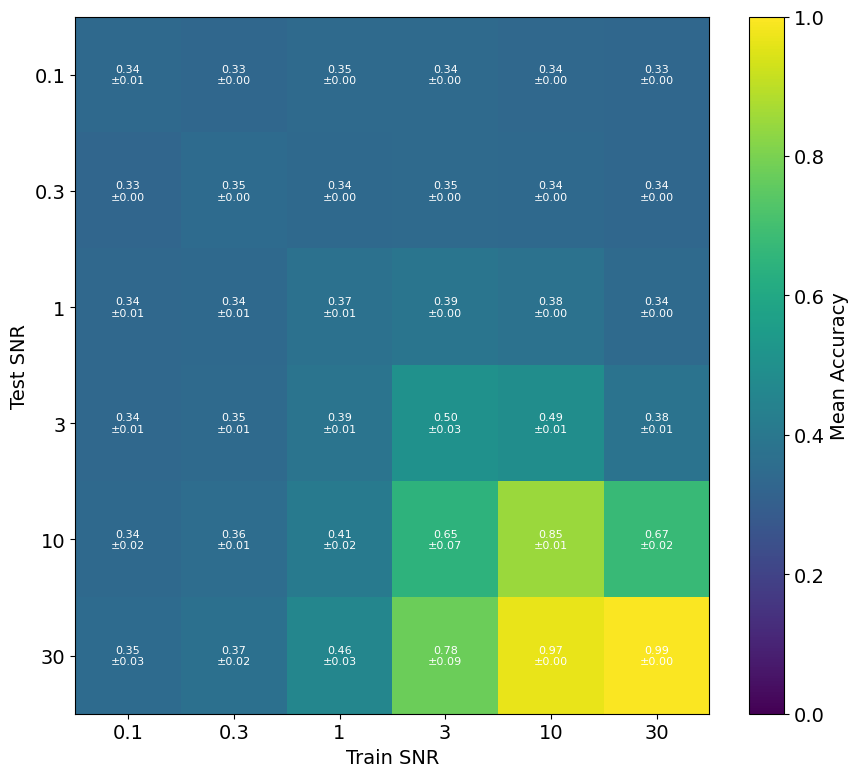

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import random
import time

# =========================================================
# PARAMETERS
# =========================================================

SNRs = [0.05, 0.15, 0.5, 1.5, 5, 15]

N = 10000
L = 60
n_class = 3

bias = 5
sigma = 20
d = 11

BATCH_SIZE = 200
EPOCHS = 250

N_RUNS = 10

# =========================================================
# PATTERN PARAMETERS
# =========================================================

pattern_params = []

for SNR in SNRs:

    A = np.sqrt(
        (2 * (np.pi + 4) * d * SNR) / (np.pi**3)
    ) * sigma

    pattern_params.append(
        (A, sigma, bias, A, sigma, bias)
    )

# =========================================================
# DATA GENERATION FUNCTION
# =========================================================

def generate_dataset(params):

    A1, DX1, bias1, A2, DX2, bias2 = params

    x = np.zeros((N, L, 2))
    y = np.zeros(N)

    for i in range(N):

        # random walk initialization
        if i > 0:

            jump0, jump1 = jump(
                bias1, bias2,
                DX1, DX2
            )

            x[i][0][0] = x[i-1][-1][0] + jump0
            x[i][0][1] = x[i-1][-1][1] + jump1

        # random walk
        for j in range(1, L):

            jump0, jump1 = jump(
                bias1, bias2,
                DX1, DX2
            )

            x[i][j][0] = x[i][j-1][0] + jump0
            x[i][j][1] = x[i][j-1][1] + jump1

        # labels
        y[i] = i % 3

        # insert pattern
        if y[i] > 0:

            j01, j02 = np.random.randint(
                0,
                L - 1 - d,
                2
            )

            sign = 3 - 2 * y[i]

            for j in range(d):

                p1, p2 = pattern(
                    j,
                    d,
                    d,
                    A1,
                    A2
                )

                x[i][j01 + j][0] += sign * p1
                x[i][j02 + j][1] += sign * p2

    return x, y.astype(np.int64)

# =========================================================
# NORMALIZATION FUNCTION
# =========================================================

def normalize_dataset(x_train, x_val):

    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)

    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)

    global_std = std_train.mean(axis=0)

    for i in range(len(x_train)):
        x_train[i] = (
            x_train[i] - xm_train[i]
        ) / global_std

    for i in range(len(x_val)):
        x_val[i] = (
            x_val[i] - xm_val[i]
        ) / global_std

    return x_train, x_val

# =========================================================
# CREATE TEST DATASETS ONCE
# =========================================================

datasets = []
labels = []

print("\nGenerating datasets...\n")

for params in pattern_params:

    x, y = generate_dataset(params)

    datasets.append(x.copy())
    labels.append(y.copy())

# =========================================================
# TRAINING
# =========================================================

all_models = []

for run in range(N_RUNS):

    print(f"\n========================")
    print(f"RUN {run+1}/{N_RUNS}")
    print(f"========================\n")

    tf.random.set_seed(run)
    np.random.seed(run)
    random.seed(run)

    run_models = []

    for snr_idx, params in enumerate(pattern_params):

        print(f"Training SNR = {SNRs[snr_idx]}")

        # -----------------------------------------
        # DATA
        # -----------------------------------------

        x = datasets[snr_idx].copy()
        y = labels[snr_idx].copy()

        y_oh = np.eye(n_class)[y]

        # split
        perc_train = 0.8
        N_train = int(perc_train * N)

        x_train = x[:N_train]
        y_train = y_oh[:N_train]

        x_val = x[N_train:]
        y_val = y_oh[N_train:]

        # normalize
        x_train, x_val = normalize_dataset(
            x_train,
            x_val
        )

        x_train = x_train.reshape(-1, L, 2)
        x_val = x_val.reshape(-1, L, 2)

        # -----------------------------------------
        # MODEL
        # -----------------------------------------

        model = BM.build_model(
            L,
            n_class=n_class
        )

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=15,
            restore_best_weights=True
        )

        start = time.time()

        fit = model.fit(
            x_train,
            y_train,
            batch_size=BATCH_SIZE,
            epochs=EPOCHS,
            validation_data=(x_val, y_val),
            verbose=False,
            shuffle=True,
            callbacks=[early_stop]
        )

        stop = time.time()

        best_acc = max(
            fit.history['val_accuracy']
        )

        print(
            f"ACC = {best_acc:.4f} | "
            f"time = {stop-start:.1f}s"
        )

        run_models.append(model)

    all_models.append(run_models)

# =========================================================
# CROSS-SNR EVALUATION
# =========================================================

print("\nEvaluating models...\n")

all_ACC = []

for run in range(N_RUNS):

    ACC = []

    for model in all_models[run]:

        accuracies = []

        for i in range(len(SNRs)):

            x_test = datasets[i].copy()

            y_test = labels[i].copy()

            # normalization
            xm = x_test.mean(axis=1)
            std = x_test.std(axis=1)

            global_std = std.mean(axis=0)

            for k in range(len(x_test)):
                x_test[k] = (
                    x_test[k] - xm[k]
                ) / global_std

            y_test_oh = np.eye(n_class)[y_test]

            loss, acc = model.evaluate(
                x_test,
                y_test_oh,
                verbose=0
            )

            accuracies.append(acc)

        ACC.append(accuracies)

    ACC = np.array(ACC).T

    all_ACC.append(ACC)

all_ACC = np.array(all_ACC)

# =========================================================
# STATISTICS
# =========================================================

ACC_mean = np.mean(all_ACC, axis=0)

ACC_std = np.std(all_ACC, axis=0)

# =========================================================
# HEATMAP
# =========================================================

plt.figure(figsize=(9, 8))

im = plt.imshow(
    ACC_mean,
    interpolation='nearest',
    aspect='auto',
    vmin=0,
    vmax=1
)

cbar = plt.colorbar(im)
cbar.set_label("Mean Accuracy")

plt.xticks(
    range(len(SNRs)),
    twoSNRs
)

plt.yticks(
    range(len(SNRs)),
    twoSNRs
)

plt.xlabel("Train SNR")
plt.ylabel("Test SNR")


# =========================================================
# TEXT INSIDE CELLS
# =========================================================

for i in range(ACC_mean.shape[0]):

    for j in range(ACC_mean.shape[1]):

        mean_val = ACC_mean[i, j]
        std_val = ACC_std[i, j]

        text = (
            f"{mean_val:.2f}\n"
            f"±{std_val:.2f}"
        )

        plt.text(
            j,
            i,
            text,
            ha='center',
            va='center',
            color='white',
            fontsize=8
        )

plt.tight_layout()

plt.savefig(
    "cross_snr_mean_std_heatmap.png",
    dpi=300
)

plt.show()

In [13]:
twoSNRs = [2, 4, 6, 8, 10]


Generating datasets...


RUN 1/10

Training SNR = 1


/home/lenovo/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ACC = 0.4360 | time = 9.3s
Training SNR = 2
ACC = 0.5485 | time = 16.0s
Training SNR = 3
ACC = 0.6890 | time = 9.9s
Training SNR = 4
ACC = 0.7585 | time = 10.9s
Training SNR = 5
ACC = 0.8480 | time = 15.6s

RUN 2/10

Training SNR = 1
ACC = 0.4435 | time = 12.1s
Training SNR = 2
ACC = 0.5520 | time = 16.7s
Training SNR = 3
ACC = 0.7040 | time = 14.4s
Training SNR = 4
ACC = 0.7695 | time = 12.7s
Training SNR = 5
ACC = 0.8235 | time = 14.8s

RUN 3/10

Training SNR = 1
ACC = 0.4575 | time = 12.0s
Training SNR = 2
ACC = 0.5760 | time = 15.4s
Training SNR = 3
ACC = 0.7130 | time = 8.2s
Training SNR = 4
ACC = 0.7615 | time = 22.7s
Training SNR = 5
ACC = 0.8485 | time = 13.5s

RUN 4/10

Training SNR = 1
ACC = 0.4275 | time = 9.4s
Training SNR = 2
ACC = 0.5765 | time = 11.9s
Training SNR = 3
ACC = 0.6660 | time = 11.1s
Training SNR = 4
ACC = 0.7675 | time = 11.7s
Training SNR = 5
ACC = 0.8430 | time = 9.6s

RUN 5/10

Training SNR = 1
ACC = 0.4315 | time = 12.6s
Training SNR = 2
ACC = 0.5530 | t

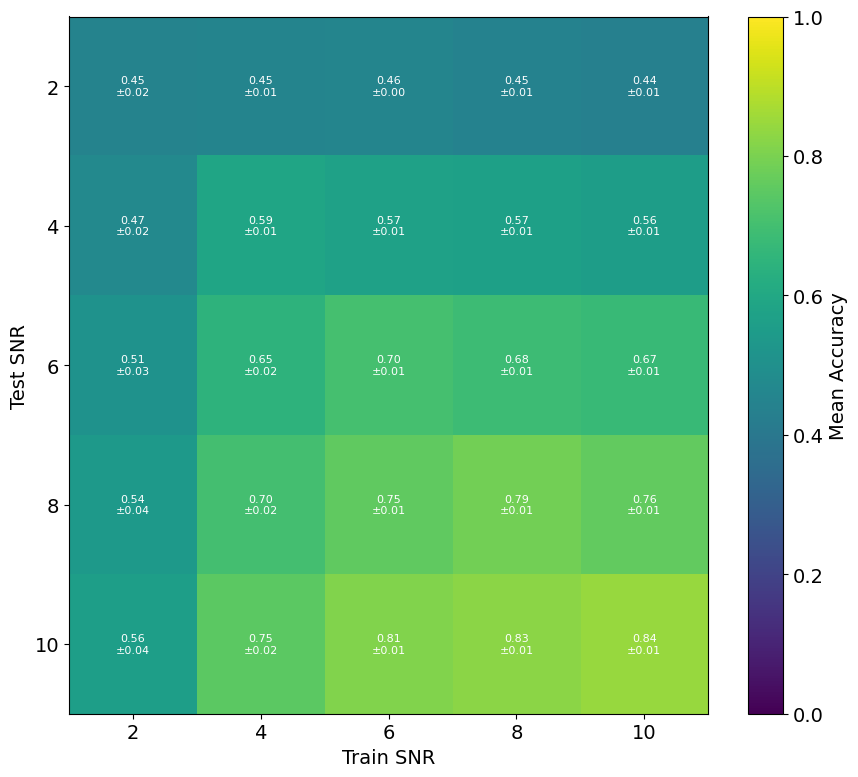

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import random
import time

# =========================================================
# PARAMETERS
# =========================================================

SNRs = [1, 2, 3, 4, 5] 

N = 10000
L = 60
n_class = 3

bias = 5
sigma = 20
d = 11

BATCH_SIZE = 200
EPOCHS = 250

N_RUNS = 10

# =========================================================
# PATTERN PARAMETERS
# =========================================================

pattern_params = []

for SNR in SNRs:

    A = np.sqrt(
        (2 * (np.pi + 4) * d * SNR) / (np.pi**3)
    ) * sigma

    pattern_params.append(
        (A, sigma, bias, A, sigma, bias)
    )

# =========================================================
# DATA GENERATION FUNCTION
# =========================================================

def generate_dataset(params):

    A1, DX1, bias1, A2, DX2, bias2 = params

    x = np.zeros((N, L, 2))
    y = np.zeros(N)

    for i in range(N):

        # random walk initialization
        if i > 0:

            jump0, jump1 = jump(
                bias1, bias2,
                DX1, DX2
            )

            x[i][0][0] = x[i-1][-1][0] + jump0
            x[i][0][1] = x[i-1][-1][1] + jump1

        # random walk
        for j in range(1, L):

            jump0, jump1 = jump(
                bias1, bias2,
                DX1, DX2
            )

            x[i][j][0] = x[i][j-1][0] + jump0
            x[i][j][1] = x[i][j-1][1] + jump1

        # labels
        y[i] = i % 3

        # insert pattern
        if y[i] > 0:

            j01, j02 = np.random.randint(
                0,
                L - 1 - d,
                2
            )

            sign = 3 - 2 * y[i]

            for j in range(d):

                p1, p2 = pattern(
                    j,
                    d,
                    d,
                    A1,
                    A2
                )

                x[i][j01 + j][0] += sign * p1
                x[i][j02 + j][1] += sign * p2

    return x, y.astype(np.int64)

# =========================================================
# NORMALIZATION FUNCTION
# =========================================================

def normalize_dataset(x_train, x_val):

    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)

    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)

    global_std = std_train.mean(axis=0)

    for i in range(len(x_train)):
        x_train[i] = (
            x_train[i] - xm_train[i]
        ) / global_std

    for i in range(len(x_val)):
        x_val[i] = (
            x_val[i] - xm_val[i]
        ) / global_std

    return x_train, x_val

# =========================================================
# CREATE TEST DATASETS ONCE
# =========================================================

datasets = []
labels = []

print("\nGenerating datasets...\n")

for params in pattern_params:

    x, y = generate_dataset(params)

    datasets.append(x.copy())
    labels.append(y.copy())

# =========================================================
# TRAINING
# =========================================================

all_models = []

for run in range(N_RUNS):

    print(f"\n========================")
    print(f"RUN {run+1}/{N_RUNS}")
    print(f"========================\n")

    tf.random.set_seed(run)
    np.random.seed(run)
    random.seed(run)

    run_models = []

    for snr_idx, params in enumerate(pattern_params):

        print(f"Training SNR = {SNRs[snr_idx]}")

        # -----------------------------------------
        # DATA
        # -----------------------------------------

        x = datasets[snr_idx].copy()
        y = labels[snr_idx].copy()

        y_oh = np.eye(n_class)[y]

        # split
        perc_train = 0.8
        N_train = int(perc_train * N)

        x_train = x[:N_train]
        y_train = y_oh[:N_train]

        x_val = x[N_train:]
        y_val = y_oh[N_train:]

        # normalize
        x_train, x_val = normalize_dataset(
            x_train,
            x_val
        )

        x_train = x_train.reshape(-1, L, 2)
        x_val = x_val.reshape(-1, L, 2)

        # -----------------------------------------
        # MODEL
        # -----------------------------------------

        model = BM.build_model(
            L,
            n_class=n_class
        )

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=15,
            restore_best_weights=True
        )

        start = time.time()

        fit = model.fit(
            x_train,
            y_train,
            batch_size=BATCH_SIZE,
            epochs=EPOCHS,
            validation_data=(x_val, y_val),
            verbose=False,
            shuffle=True,
            callbacks=[early_stop]
        )

        stop = time.time()

        best_acc = max(
            fit.history['val_accuracy']
        )

        print(
            f"ACC = {best_acc:.4f} | "
            f"time = {stop-start:.1f}s"
        )

        run_models.append(model)

    all_models.append(run_models)

# =========================================================
# CROSS-SNR EVALUATION
# =========================================================

print("\nEvaluating models...\n")

all_ACC = []

for run in range(N_RUNS):

    ACC = []

    for model in all_models[run]:

        accuracies = []

        for i in range(len(SNRs)):

            x_test = datasets[i].copy()

            y_test = labels[i].copy()

            # normalization
            xm = x_test.mean(axis=1)
            std = x_test.std(axis=1)

            global_std = std.mean(axis=0)

            for k in range(len(x_test)):
                x_test[k] = (
                    x_test[k] - xm[k]
                ) / global_std

            y_test_oh = np.eye(n_class)[y_test]

            loss, acc = model.evaluate(
                x_test,
                y_test_oh,
                verbose=0
            )

            accuracies.append(acc)

        ACC.append(accuracies)

    ACC = np.array(ACC).T

    all_ACC.append(ACC)

all_ACC = np.array(all_ACC)

# =========================================================
# STATISTICS
# =========================================================

ACC_mean = np.mean(all_ACC, axis=0)

ACC_std = np.std(all_ACC, axis=0)

# =========================================================
# HEATMAP
# =========================================================

plt.figure(figsize=(9, 8))

im = plt.imshow(
    ACC_mean,
    interpolation='nearest',
    aspect='auto',
    vmin=0,
    vmax=1
)

cbar = plt.colorbar(im)
cbar.set_label("Mean Accuracy")

plt.xticks(
    range(len(SNRs)),
    twoSNRs
)

plt.yticks(
    range(len(SNRs)),
    twoSNRs
)

plt.xlabel("Train SNR")
plt.ylabel("Test SNR")


# =========================================================
# TEXT INSIDE CELLS
# =========================================================

for i in range(ACC_mean.shape[0]):

    for j in range(ACC_mean.shape[1]):

        mean_val = ACC_mean[i, j]
        std_val = ACC_std[i, j]

        text = (
            f"{mean_val:.2f}\n"
            f"±{std_val:.2f}"
        )

        plt.text(
            j,
            i,
            text,
            ha='center',
            va='center',
            color='white',
            fontsize=8
        )

plt.tight_layout()

plt.savefig(
    "cross_snr_mean_std_heatmap_2to10.png",
    dpi=300
)

plt.show()

In [15]:
# ======================================
# COLUMN MEAN EXCLUDING DIAGONAL
# ======================================

col_means = []

for i in range(len(SNRs)):

    # rimuove elemento diagonale
    values = np.delete(ACC_mean[:, i], i)

    col_means.append(values.mean())

col_means = np.array(col_means)

print("Column means:")
print(col_means)

# best training SNR
max_idx = np.argmax(col_means)

max_val = col_means[max_idx]

print("\nBest generalization SNR")
print("-----------------------")

print(f"Mean accuracy = {max_val:.4f}")

print(f"SNR = {twoSNRs[max_idx]}")

Column means:
[0.51986    0.6372875  0.64802    0.6312025  0.60613501]

Best generalization SNR
-----------------------
Mean accuracy = 0.6480
SNR = 6
